<a href="https://colab.research.google.com/github/BavaDharaniBR/Customer-LTV-Prediction/blob/main/ISIcoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_excel("Copy of Online Retail.xlsx")

# Original shape
print("Original Shape:", df.shape)

# 1. Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# 2. Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Remove negative or zero quantities
df = df[df['Quantity'] > 0]

# 4. Remove zero or negative prices
df = df[df['UnitPrice'] > 0]

# 5. Remove duplicate rows
df = df.drop_duplicates()

# 6. Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 7. Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

# 8. Create Revenue column
df['Revenue'] = df['Quantity']*df['UnitPrice']

print("Cleaned Shape:", df.shape)


print("\nMissing CustomerID:", df['CustomerID'].isnull().sum())
print("Duplicates:", df.duplicated().sum())
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("UnitPrice <= 0:", (df['UnitPrice'] <= 0).sum())


df.to_excel("cleaned_full_online_retail.xlsx", index=False)

print("\nCleaning completed successfully!")

Original Shape: (541909, 8)
Cleaned Shape: (392692, 9)

Missing CustomerID: 0
Duplicates: 0
Quantity <= 0: 0
UnitPrice <= 0: 0

Cleaning completed successfully!


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [ ]:
print("Unique Customers:", df['CustomerID'].nunique())

Unique Customers: 4338


In [ ]:
df = pd.read_excel("cleaned_full_online_retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [ ]:
snapshot_date = df['InvoiceDate'].max()

print(snapshot_date)

2011-12-09 12:50:00


In [ ]:
rfm = df.groupby('CustomerID').agg({'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
                                    'InvoiceNo': 'nunique','Revenue': 'sum'})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.shape)
rfm.head()

(4338, 3)


,Recency,Frequency,Monetary
CustomerID,,,
12346,325,1,77183.60
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40


In [ ]:
df['InvoiceDate'].min()
df['InvoiceDate'].max()
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


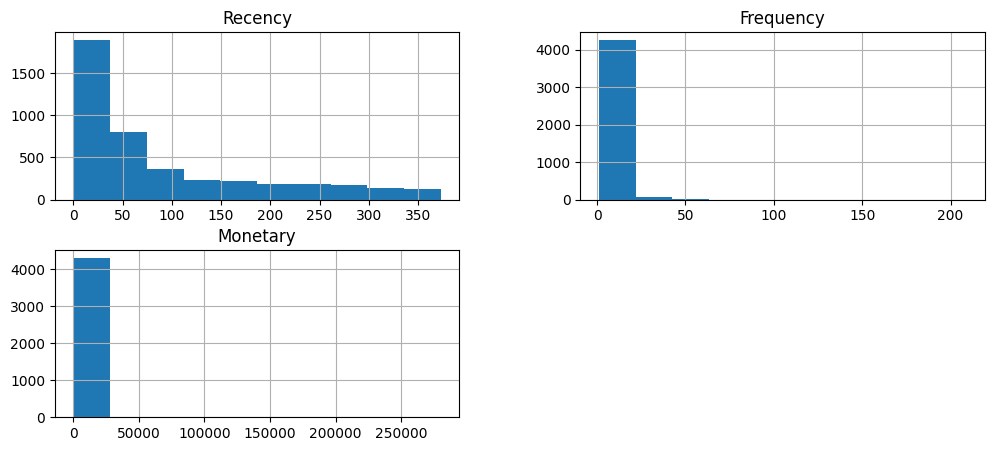

In [ ]:
import matplotlib.pyplot as plt

rfm.hist(figsize=(12,5))
plt.show()

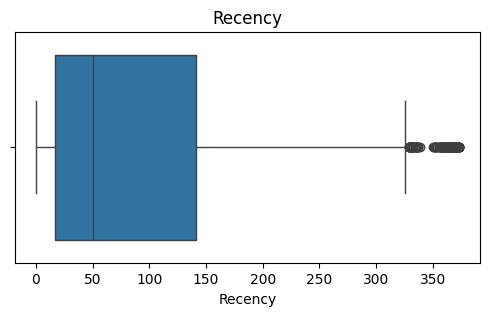

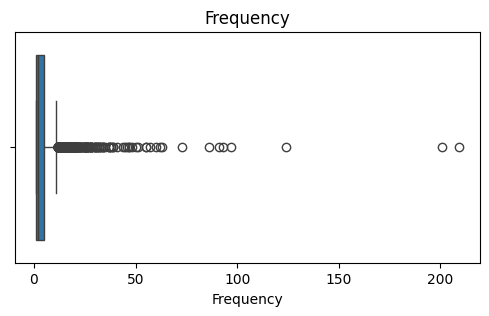

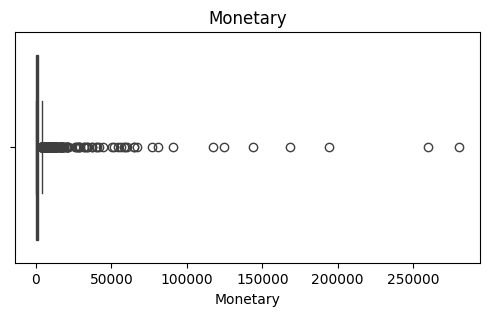

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in rfm.columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=rfm[col])
    plt.title(col)
    plt.show()

In [ ]:
import numpy as np

rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

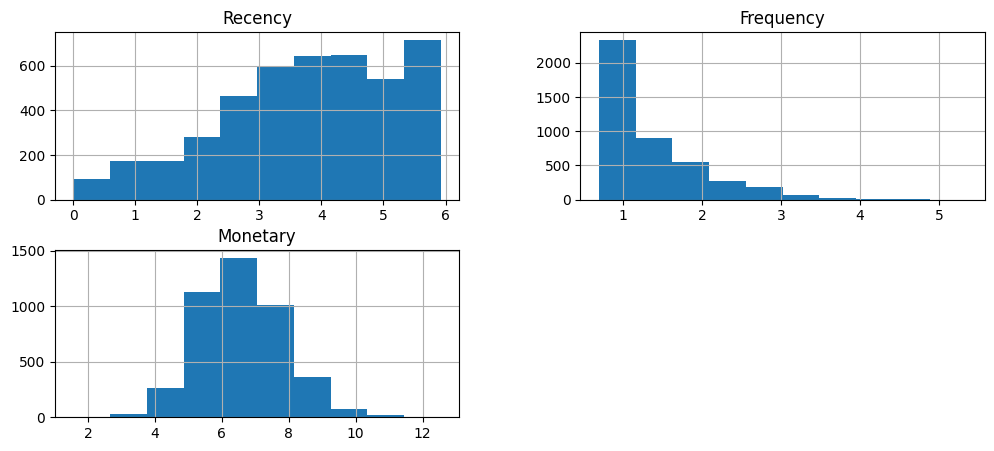

In [ ]:
rfm_log.hist(figsize=(12,5))
plt.show()

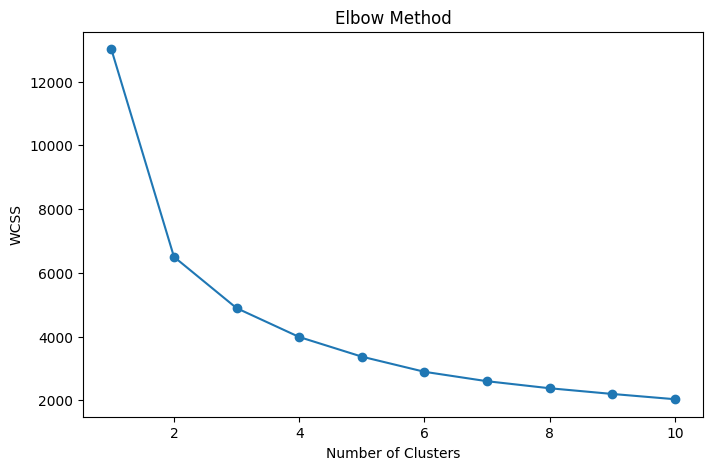

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10)

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,325,1,77183.60,3
12347,1,7,4310.00,2
12348,74,4,1797.24,3
12349,18,1,1757.55,0
12350,309,1,334.40,1


In [ ]:
rfm['Cluster'].value_counts()

,count
Cluster,
1,1642
3,1203
0,808
2,685


In [ ]:
cluster_summary = rfm.groupby('Cluster').agg({'Recency':'mean','Frequency':'mean',
                                              'Monetary':'mean'}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,17.06,2.12,540.35
1,179.43,1.32,347.61
2,10.39,13.99,8290.35
3,67.80,4.21,1829.55


In [ ]:
segment_map = {
    0: 'Regular Customers',
    1: 'At-Risk Customers',
    2: 'VIP Customers',
    3: 'Loyal Customers'}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346,325,1,77183.60,3,Loyal Customers
12347,1,7,4310.00,2,VIP Customers
12348,74,4,1797.24,3,Loyal Customers
12349,18,1,1757.55,0,Regular Customers
12350,309,1,334.40,1,At-Risk Customers


In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
At-Risk Customers,1642
Loyal Customers,1203
Regular Customers,808
VIP Customers,685


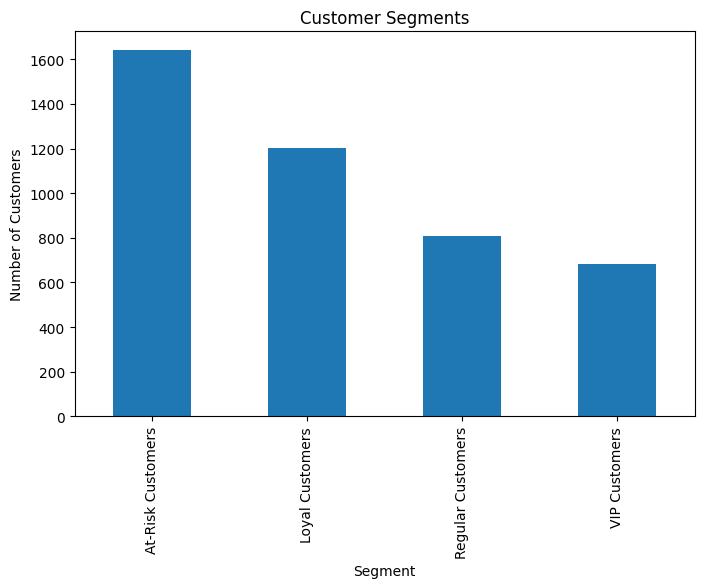

In [ ]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar',figsize=(8,5))

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

rfm['Segment_Encoded'] = le.fit_transform(rfm['Segment'])

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment,Segment_Encoded
CustomerID,,,,,,
12346,325,1,77183.60,3,Loyal Customers,1
12347,1,7,4310.00,2,VIP Customers,3
12348,74,4,1797.24,3,Loyal Customers,1
12349,18,1,1757.55,0,Regular Customers,2
12350,309,1,334.40,1,At-Risk Customers,0


In [ ]:
X = rfm[['Recency', 'Frequency', 'Segment_Encoded']]

y = rfm['Monetary']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, y_pred_lr))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

print("R2 :", r2_score(y_test, y_pred_lr))

Linear Regression
MAE : 1480.5104209902006
RMSE : 8209.916170570503
R2 : 0.3412696139986977


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
print("Decision Tree")

print("MAE :", mean_absolute_error(y_test, y_pred_dt))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

print("R2 :", r2_score(y_test, y_pred_dt))

Decision Tree
MAE : 1985.3180370973112
RMSE : 12026.407768103574
R2 : -0.4135204685977063


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100,random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test, y_pred_rf))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

print("R2 :", r2_score(y_test, y_pred_rf))

Random Forest
MAE : 1817.1415029682526
RMSE : 10571.481667494534
R2 : -0.09219950094248186


In [ ]:
results = {'Model': ['Linear Regression','Decision Tree','Random Forest'],
           'MAE': [mean_absolute_error(y_test, y_pred_lr),
                   mean_absolute_error(y_test, y_pred_dt),
                   mean_absolute_error(y_test, y_pred_rf)],
           'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
                    np.sqrt(mean_squared_error(y_test, y_pred_dt)),
                    np.sqrt(mean_squared_error(y_test, y_pred_rf))],
           'R2 Score': [r2_score(y_test, y_pred_lr),
                        r2_score(y_test, y_pred_dt),
                        r2_score(y_test, y_pred_rf)]}

import pandas as pd

comparison = pd.DataFrame(results)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1480.510421,8209.916171,0.34127
1,Decision Tree,1985.318037,12026.407768,-0.41352
2,Random Forest,1817.141503,10571.481667,-0.09220


In [ ]:
comparison.sort_values(
    by='R2 Score',
    ascending=False)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1480.510421,8209.916171,0.34127
2,Random Forest,1817.141503,10571.481667,-0.09220
1,Decision Tree,1985.318037,12026.407768,-0.41352


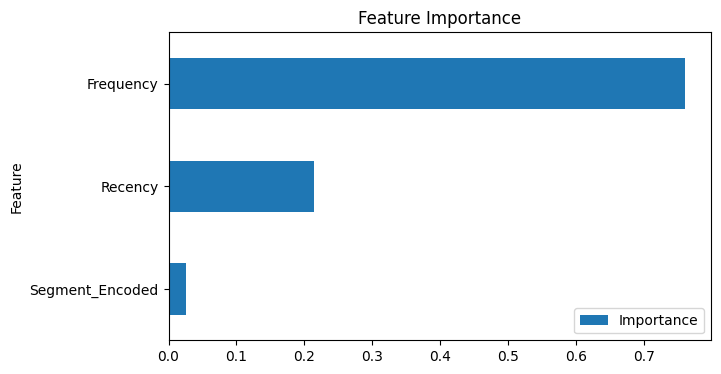

In [ ]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_})

importance.sort_values(
    by='Importance',
    ascending=True).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(7,4))

plt.title("Feature Importance")
plt.show()

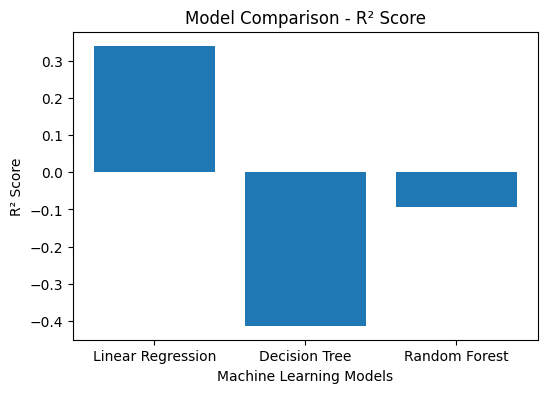

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(comparison['Model'], comparison['R2 Score'])

plt.title("Model Comparison - R² Score")
plt.xlabel("Machine Learning Models")
plt.ylabel("R² Score")

plt.show()

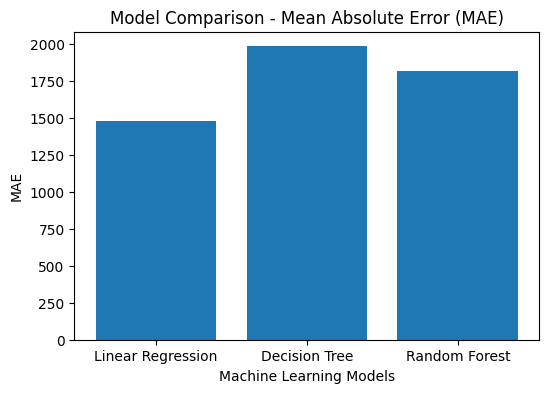

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(comparison['Model'], comparison['MAE'])

plt.title("Model Comparison - Mean Absolute Error (MAE)")
plt.xlabel("Machine Learning Models")
plt.ylabel("MAE")

plt.show()

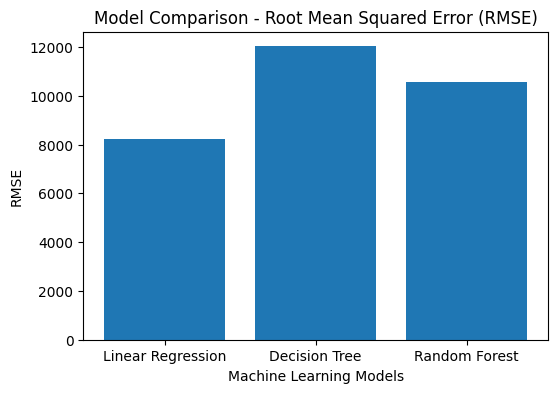

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(comparison['Model'], comparison['RMSE'])

plt.title("Model Comparison - Root Mean Squared Error (RMSE)")
plt.xlabel("Machine Learning Models")
plt.ylabel("RMSE")

plt.show()